# Unsupervised Learning: Clustering Kelas Engagement Daily Trending Video Youtube

Tujuan: membentuk kelas engagement (low, medium, high) memakai clustering tanpa label.

Aktifkan virtual environment sebelum menjalankan notebook:
- source ~/venv/bin/activate
- pip install -r requirements.txt

## Muat Library Python

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

from sklearn.preprocessing import PowerTransformer, RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.cluster import Birch, KMeans, MiniBatchKMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    accuracy_score,
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    f1_score,
    normalized_mutual_info_score,
    silhouette_score,
)

sns.set_theme(style="whitegrid")


## Muat dan Filter Dataset 2025
Jika kolom tanggal ditemukan, data difilter ke tahun 2025. Jika tidak, gunakan semua data.

In [25]:
def pick_date_column(columns):
    priority = ["publish", "published", "trending", "date", "time"]
    ranked = []
    for col in columns:
        lower = col.lower()
        hits = [priority.index(k) for k in priority if k in lower]
        if hits:
            ranked.append((min(hits), col))
    ranked.sort(key=lambda x: x[0])
    return ranked[0][1] if ranked else None


def pick_column(columns, candidates):
    lower_map = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand in lower_map:
            return lower_map[cand]
    for col in columns:
        lower = col.lower()
        if any(cand in lower for cand in candidates):
            return col
    return None


data_path = Path("daily_trending_videos.csv")
if not data_path.exists():
    data_path = Path("/root/machine_learning/project/daily_trending_videos.csv")
df = pd.read_csv(data_path, low_memory=False)
print("Shape awal:", df.shape)

print("Kolom:", df.columns.tolist())

# Filter tahun 2025 jika ada kolom tanggal
_date_col = pick_date_column(df.columns)
if _date_col:
    df[_date_col] = pd.to_datetime(df[_date_col], errors="coerce", utc=True)
    before = len(df)
    df_2025 = df[df[_date_col].dt.year == 2025].copy()
    if df_2025.empty:
        print("Tidak ada data tahun 2025 pada kolom", _date_col, "- gunakan semua data.")
        df_2025 = df.copy()
    after = len(df_2025)
    print(f"Filter 2025 menggunakan {_date_col}: {before} -> {after}")
else:
    print("Kolom tanggal tidak ditemukan - gunakan semua data.")
    df_2025 = df.copy()

# Identifikasi kolom penting
views_col = pick_column(df_2025.columns, ["view_count", "views", "viewcount"])
likes_col = pick_column(df_2025.columns, ["like_count", "likes", "likecount"])
comments_col = pick_column(df_2025.columns, ["comment_count", "comments", "commentcount"])
video_id_col = pick_column(df_2025.columns, ["video_id", "videoid"])

# Konversi metrik utama ke numerik
for col in [views_col, likes_col, comments_col]:
    if col is not None:
        df_2025[col] = pd.to_numeric(df_2025[col], errors="coerce").fillna(0)

# Cleaning Noise: Hapus baris dengan views <= 0
before_noise = len(df_2025)
if views_col is not None:
    df_2025 = df_2025[df_2025[views_col] > 0].copy()
print("Noise (views <= 0) dihapus:", before_noise, "->", len(df_2025))

# Cleaning Duplikat Semantik berdasarkan video_id dengan mempertahankan views tertinggi
before_dup = len(df_2025)
if video_id_col is not None and views_col is not None:
    df_2025 = df_2025.sort_values(by=views_col, ascending=False)
    df_2025 = df_2025.drop_duplicates(subset=[video_id_col], keep="first").reset_index(drop=True)
else:
    df_2025 = df_2025.drop_duplicates().reset_index(drop=True)

# PISAHKAN DATA ASLI DI LUAR DATASET UNTUK PENGUJIAN EKSTERNAL (Out-of-Dataset)
# Kita ambil 10 baris data video nyata secara acak dan keluarkan dari dataset pemodelan
df_external_test = df_2025.sample(n=10, random_state=100).copy()
df_2025 = df_2025.drop(df_external_test.index).reset_index(drop=True)
df = df_2025.copy()
df_external_test = df_external_test.reset_index(drop=True)

print("Duplikat semantik berdasarkan video_id (views tertinggi) dihapus:", before_dup, "->", len(df))
print(f"Data asli di luar dataset dipisahkan untuk pengujian eksternal: {df_external_test.shape[0]} baris")


Shape awal: (674141, 9)
Kolom: ['video_id', 'title', 'channel', 'country', 'views', 'likes', 'comments', 'published_at', 'fetch_date']
Filter 2025 menggunakan published_at: 674141 -> 674141
Noise (views <= 0) dihapus: 674141 -> 673759
Duplikat semantik berdasarkan video_id (views tertinggi) dihapus: 673759 -> 52184
Data asli di luar dataset dipisahkan untuk pengujian eksternal: 10 baris


## Hitung Engagement Rate
Engagement rate dihitung dari likes dan comments dibanding views.

In [26]:
def pick_column(columns, candidates):
    lower_map = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand in lower_map:
            return lower_map[cand]
    for col in columns:
        lower = col.lower()
        if any(cand in lower for cand in candidates):
            return col
    return None

views_col = pick_column(df.columns, ["view_count", "views", "viewcount"])
likes_col = pick_column(df.columns, ["like_count", "likes", "likecount"])
comments_col = pick_column(df.columns, ["comment_count", "comments", "commentcount"])
video_id_col = pick_column(df.columns, ["video_id", "videoid"])

missing = [name for name, col in [("views", views_col), ("likes", likes_col), ("comments", comments_col)] if col is None]
if missing:
    raise ValueError(f"Kolom metrik tidak ditemukan: {missing}")

for col in [views_col, likes_col, comments_col]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df["engagement_rate"] = (df[likes_col] + df[comments_col]) / df[views_col].replace(0, np.nan)
df["engagement_rate"] = df["engagement_rate"].fillna(0)

# Threshold yang sama dengan supervised_engagement.ipynb supaya hasil bisa dibandingkan.
low_max = 0.02
medium_max = 0.06
if low_max >= medium_max:
    raise ValueError("Threshold tidak valid: low_max harus < medium_max")


def assign_class(x):
    if x <= low_max:
        return "low"
    if x <= medium_max:
        return "medium"
    return "high"


df["engagement_class"] = df["engagement_rate"].apply(assign_class)

print("Threshold rule-based:", low_max, medium_max)
print("Distribusi engagement_class:")
print(df["engagement_class"].value_counts())
print(df[[views_col, likes_col, comments_col, "engagement_rate", "engagement_class"]].head())


Threshold rule-based: 0.02 0.06
Distribusi engagement_class:
engagement_class
medium    25460
low       17462
high       9262
Name: count, dtype: int64
       views    likes  comments  engagement_rate engagement_class
0  316012253  8548843      6173         0.027072           medium
1  291765716  3919882      4729         0.013451              low
2  253675618  5511355     16933         0.021793           medium
3  238876946  6104517     10256         0.025598           medium
4  232971025  2635750      2937         0.011326              low


## Unsupervised Learning: Clustering Engagement
Tingkatkan kualitas input KMeans dengan transformasi distribusi, scaling, dan PCA. Fitur numerik mentah ditransformasi memakai PowerTransformer Yeo-Johnson, diskalakan dengan RobustScaler jika outlier terdeteksi, lalu direduksi dengan PCA sampai mempertahankan minimal 95% varians data. Komponen PCA dipakai sebagai input clustering.


In [27]:
def ensure_engagement_inputs(df_source):
    def resolve_column(columns, candidates):
        lower_map = {c.lower(): c for c in columns}
        for cand in candidates:
            if cand in lower_map:
                return lower_map[cand]
        for col in columns:
            lower = col.lower()
            if any(cand in lower for cand in candidates):
                return col
        return None

    resolved_views_col = globals().get("views_col") or resolve_column(df_source.columns, ["view_count", "views", "viewcount"])
    resolved_likes_col = globals().get("likes_col") or resolve_column(df_source.columns, ["like_count", "likes", "likecount"])
    resolved_comments_col = globals().get("comments_col") or resolve_column(df_source.columns, ["comment_count", "comments", "commentcount"])
    resolved_video_id_col = globals().get("video_id_col") or resolve_column(df_source.columns, ["video_id", "videoid"])

    missing = [
        name
        for name, col in [
            ("views", resolved_views_col),
            ("likes", resolved_likes_col),
            ("comments", resolved_comments_col),
        ]
        if col is None
    ]
    if missing:
        raise ValueError(f"Kolom metrik tidak ditemukan: {missing}")

    for col in [resolved_views_col, resolved_likes_col, resolved_comments_col]:
        df_source[col] = pd.to_numeric(df_source[col], errors="coerce").fillna(0)

    if "engagement_rate" not in df_source.columns:
        df_source["engagement_rate"] = (
            df_source[resolved_likes_col] + df_source[resolved_comments_col]
        ) / df_source[resolved_views_col].replace(0, np.nan)
        df_source["engagement_rate"] = df_source["engagement_rate"].fillna(0)
        print("Kolom engagement_rate belum ada, jadi dihitung ulang dari likes/comments/views.")

    if "engagement_class" not in df_source.columns:
        if "low_max" not in globals():
            globals()["low_max"] = 0.02
        if "medium_max" not in globals():
            globals()["medium_max"] = 0.06

        def assign_engagement_class(x):
            if x <= low_max:
                return "low"
            if x <= medium_max:
                return "medium"
            return "high"

        df_source["engagement_class"] = df_source["engagement_rate"].apply(assign_engagement_class)
        print("Kolom engagement_class belum ada, jadi dibuat ulang dari threshold rule-based.")

    return resolved_views_col, resolved_likes_col, resolved_comments_col, resolved_video_id_col

views_col, likes_col, comments_col, video_id_col = ensure_engagement_inputs(df)


## Eksperimen Preprocessing (PCA vs Tanpa PCA & Robust vs Standard Scaler)
Sesuai dengan rekomendasi evaluasi, kita akan menguji performa clustering secara empiris menggunakan **16 kombinasi model**:
- **Scaler**: RobustScaler vs StandardScaler
- **PCA**: PCA (minimal 95% variansi) vs Tanpa PCA (menggunakan ruang fitur asli)
- **Clustering**: KMeans, MiniBatchKMeans, GMM, Birch

Pemisahan dataset dilakukan dengan rasio **1:1 Train/Test split**. Pipeline preprocessing di-fit **hanya pada Train Set** untuk mencegah kebocoran data (*data leakage*).

In [28]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, RobustScaler, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, MiniBatchKMeans, Birch
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    accuracy_score,
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    f1_score,
    normalized_mutual_info_score,
    silhouette_score,
)

CLUSTER_LEVELS = ["low", "medium", "high"]
METRIC_SAMPLE_SIZE = 5000
RANDOM_STATE = 42
PCA_VARIANCE_TARGET = 0.95
OUTLIER_CONTAMINATION = 0.03

# Split Train-Test 1:1 untuk pengujian generalisasi
df_train, df_test = train_test_split(df, test_size=0.5, random_state=RANDOM_STATE)
df_train = df_train.copy()
df_test = df_test.copy()

print(f"Dataset split (1:1): Train={len(df_train)}, Test={len(df_test)}")

# Helper untuk metrik internal
def sample_indices_for_metric(n_rows, max_sample=METRIC_SAMPLE_SIZE, random_state=RANDOM_STATE):
    if n_rows <= max_sample:
        return np.arange(n_rows)
    rng = np.random.default_rng(random_state)
    return np.sort(rng.choice(n_rows, size=max_sample, replace=False))

def safe_internal_metrics(X, labels):
    labels = np.asarray(labels)
    unique_labels, counts = np.unique(labels, return_counts=True)
    metrics = {
        "cluster_count": len(unique_labels),
        "min_cluster_size": counts.min() if len(counts) else 0,
        "max_cluster_size": counts.max() if len(counts) else 0,
        "silhouette_sampled": np.nan,
        "calinski_harabasz": np.nan,
        "davies_bouldin": np.nan,
    }
    if len(unique_labels) <= 1 or len(unique_labels) >= len(labels):
        return metrics
    sample_idx = sample_indices_for_metric(len(labels))
    X_sample = X[sample_idx]
    labels_sample = labels[sample_idx]
    if 1 < len(np.unique(labels_sample)) < len(labels_sample):
        metrics["silhouette_sampled"] = silhouette_score(X_sample, labels_sample)
    metrics["calinski_harabasz"] = calinski_harabasz_score(X, labels)
    metrics["davies_bouldin"] = davies_bouldin_score(X, labels)
    return metrics

def map_cluster_to_engagement_level(train_labels, train_engagement_rate):
    # Mapping di-fit hanya menggunakan Train Set untuk menghindari leakage
    summary = (
        pd.DataFrame({"cluster_label": train_labels, "engagement_rate": train_engagement_rate})
        .groupby("cluster_label")["engagement_rate"]
        .mean()
        .sort_values()
    )
    if len(summary) != len(CLUSTER_LEVELS):
        return {label: f"cluster_{label}" for label in summary.index}
    return dict(zip(summary.index, CLUSTER_LEVELS))

# Eksperimen kombinasi preprocessing
configs = [
    {"use_robust_scaler": True, "use_pca": True, "suffix": "Robust_PCA"},
    {"use_robust_scaler": True, "use_pca": False, "suffix": "Robust_NoPCA"},
    {"use_robust_scaler": False, "use_pca": True, "suffix": "Standard_PCA"},
    {"use_robust_scaler": False, "use_pca": False, "suffix": "Standard_NoPCA"},
]

results = []
trained_models = {}

for config in configs:
    use_robust = config["use_robust_scaler"]
    use_pca = config["use_pca"]
    suffix = config["suffix"]
    
    # Raw features
    raw_train = pd.DataFrame({
        "views": df_train[views_col],
        "likes": df_train[likes_col],
        "comments": df_train[comments_col],
        "engagement_rate": df_train["engagement_rate"],
    })
    raw_test = pd.DataFrame({
        "views": df_test[views_col],
        "likes": df_test[likes_col],
        "comments": df_test[comments_col],
        "engagement_rate": df_test["engagement_rate"],
    })
    
    # Yeo-Johnson PowerTransformer
    pt = PowerTransformer(method="yeo-johnson", standardize=False)
    X_train_pt = pt.fit_transform(raw_train)
    X_test_pt = pt.transform(raw_test)
    
    # Scaler
    scaler = RobustScaler() if use_robust else StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_pt)
    X_test_scaled = scaler.transform(X_test_pt)
    
    # Outlier Removal dengan Isolation Forest (di-fit HANYA pada Train Set)
    od = IsolationForest(n_estimators=200, contamination=OUTLIER_CONTAMINATION, random_state=RANDOM_STATE, n_jobs=-1)
    train_outliers = od.fit_predict(X_train_scaled)
    test_outliers = od.predict(X_test_scaled)
    
    inliers_train = train_outliers == 1
    inliers_test = test_outliers == 1
    
    X_train_scaled_clean = X_train_scaled[inliers_train]
    X_test_scaled_clean = X_test_scaled[inliers_test]
    
    df_train_clean = df_train[inliers_train].copy()
    df_test_clean = df_test[inliers_test].copy()
    
    # PCA
    if use_pca:
        pca = PCA(n_components=PCA_VARIANCE_TARGET, svd_solver="full", random_state=RANDOM_STATE)
        X_train_final = pca.fit_transform(X_train_scaled_clean)
        X_test_final = pca.transform(X_test_scaled_clean)
        pca_comps = X_train_final.shape[1]
    else:
        X_train_final = X_train_scaled_clean
        X_test_final = X_test_scaled_clean
        pca = None
        pca_comps = X_train_final.shape[1]
        
    model_specs = [
        ("KMeans", KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10, algorithm="elkan"), "kmeans"),
        ("MiniBatchKMeans", MiniBatchKMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10, batch_size=4096), "minibatch_kmeans"),
        ("GaussianMixture", GaussianMixture(n_components=3, covariance_type="full", random_state=RANDOM_STATE, n_init=3), "gaussian_mixture"),
        ("Birch", Birch(n_clusters=3, threshold=0.5), "birch"),
    ]
    
    for model_name, model_inst, prefix in model_specs:
        method_full_name = f"{model_name}_{suffix}"
        
        # Fit model
        model_inst.fit(X_train_final)
        
        if hasattr(model_inst, "labels_"):
            train_labels = model_inst.labels_
        else:
            train_labels = model_inst.predict(X_train_final)
            
        if hasattr(model_inst, "predict"):
            test_labels = model_inst.predict(X_test_final)
        else:
            test_labels = model_inst.fit_predict(X_test_final)
            
        # Map cluster ke level engagement
        cluster_map = map_cluster_to_engagement_level(train_labels, df_train_clean["engagement_rate"])
        train_levels = pd.Series(train_labels).map(cluster_map).to_numpy()
        test_levels = pd.Series(test_labels).map(cluster_map).to_numpy()
        
        # Evaluasi
        train_internal = safe_internal_metrics(X_train_final, train_labels)
        test_internal = safe_internal_metrics(X_test_final, test_labels)
        
        train_ari = adjusted_rand_score(df_train_clean["engagement_class"], train_levels)
        test_ari = adjusted_rand_score(df_test_clean["engagement_class"], test_levels)
        
        train_nmi = normalized_mutual_info_score(df_train_clean["engagement_class"], train_levels)
        test_nmi = normalized_mutual_info_score(df_test_clean["engagement_class"], test_levels)
        
        train_acc = accuracy_score(df_train_clean["engagement_class"], train_levels)
        test_acc = accuracy_score(df_test_clean["engagement_class"], test_levels)
        train_f1 = f1_score(df_train_clean["engagement_class"], train_levels, average="weighted")
        test_f1 = f1_score(df_test_clean["engagement_class"], test_levels, average="weighted")
        
        row = {
            "method": method_full_name,
            "model_type": model_name,
            "config": suffix,
            "scaler": "RobustScaler" if use_robust else "StandardScaler",
            "pca_used": use_pca,
            "pca_components": pca_comps,
            "train_silhouette": train_internal["silhouette_sampled"],
            "test_silhouette": test_internal["silhouette_sampled"],
            "train_ari": train_ari,
            "test_ari": test_ari,
            "train_nmi": train_nmi,
            "test_nmi": test_nmi,
            "train_accuracy": train_acc,
            "test_accuracy": test_acc,
            "train_f1_weighted": train_f1,
            "test_f1_weighted": test_f1,
            # Backward compatibility
            "column_prefix": f"{prefix}_{suffix.lower()}",
            "silhouette_sampled": test_internal["silhouette_sampled"],
            "ari_vs_rule": test_ari,
            "nmi_vs_rule": test_nmi,
            "accuracy_vs_rule": test_acc,
            "f1_weighted_vs_rule": test_f1,
            "cluster_count": len(np.unique(train_labels)),
            "min_cluster_size": train_internal["min_cluster_size"],
            "max_cluster_size": train_internal["max_cluster_size"],
        }
        
        results.append(row)
        
        trained_models[method_full_name] = {
            "model": model_inst,
            "power_transformer": pt,
            "scaler": scaler,
            "pca": pca,
            "inliers_train": inliers_train,
            "inliers_test": inliers_test,
            "cluster_map": cluster_map,
            "prefix": f"{prefix}_{suffix.lower()}",
        }

model_comparison_df = pd.DataFrame(results)
model_comparison_df = model_comparison_df.sort_values(
    ["test_f1_weighted", "test_ari", "test_silhouette"],
    ascending=[False, False, False],
).reset_index(drop=True)

print("Eksperimen selesai! Berikut hasil perbandingan model (diurutkan berdasarkan F1 Weighted pada Test Set):")
display(model_comparison_df[[
    "method", "train_silhouette", "test_silhouette", 
    "train_ari", "test_ari", 
    "train_accuracy", "test_accuracy", 
    "train_f1_weighted", "test_f1_weighted"
]])


Dataset split (1:1): Train=26092, Test=26092
Eksperimen selesai! Berikut hasil perbandingan model (diurutkan berdasarkan F1 Weighted pada Test Set):


,method,train_silhouette,test_silhouette,train_ari,test_ari,train_accuracy,test_accuracy,train_f1_weighted,test_f1_weighted
0,MiniBatchKMeans_Standard_NoPCA,0.284362,0.286367,0.179273,0.185109,0.564029,0.566095,0.555448,0.557679
1,KMeans_Standard_PCA,0.293085,0.291677,0.157942,0.159956,0.558062,0.558707,0.545550,0.546534
2,KMeans_Standard_NoPCA,0.291389,0.290005,0.157585,0.159919,0.557825,0.558707,0.544797,0.546015
3,MiniBatchKMeans_Standard_PCA,0.294888,0.292588,0.160191,0.162231,0.551978,0.553611,0.533812,0.536045
4,KMeans_Robust_PCA,0.264146,0.262965,0.137496,0.140388,0.516615,0.519912,0.506338,0.509835
5,KMeans_Robust_NoPCA,0.261942,0.260860,0.131337,0.135648,0.509384,0.511971,0.497568,0.500395
6,GaussianMixture_Robust_PCA,0.197278,0.197565,0.253280,0.258580,0.534474,0.534332,0.493694,0.497163
7,MiniBatchKMeans_Robust_PCA,0.234926,0.233769,0.058861,0.060172,0.477063,0.480563,0.481994,0.485846
8,GaussianMixture_Standard_PCA,0.226523,0.226075,0.203456,0.205459,0.531313,0.530815,0.482629,0.484420
9,Birch_Standard_NoPCA,0.180869,0.178213,0.069326,0.068978,0.465131,0.465905,0.460156,0.462452


## Pemilihan Model Terbaik & Penyelarasan Output
Kita memilih kombinasi model dan preprocessing dengan skor **F1-Weighted Test Set** tertinggi. Kita petakan kembali hasil prediksinya ke DataFrame `df` asli untuk menjaga kompatibilitas, serta mengekspor parameter ringkasan preprocessing dan deteksi outlier.

In [29]:
best_model_row = model_comparison_df.iloc[0].to_dict()
best_method_name = best_model_row["method"]
best_prefix = best_model_row["column_prefix"]
best_model_info = trained_models[best_method_name]

print(f"Model Terbaik Terpilih: {best_method_name} (Test F1: {best_model_row['test_f1_weighted']:.4f})")

# Beri label klaster pada df_train dan df_test untuk seluruh model untuk kompatibilitas
for method_name, info in trained_models.items():
    prefix = info["prefix"]
    pt = info["power_transformer"]
    scaler = info["scaler"]
    pca = info["pca"]
    model_inst = info["model"]
    cluster_map = info["cluster_map"]
    
    # Train
    raw_tr = pd.DataFrame({
        "views": df_train[views_col], 
        "likes": df_train[likes_col], 
        "comments": df_train[comments_col], 
        "engagement_rate": df_train["engagement_rate"]
    })
    X_tr_pt = pt.transform(raw_tr)
    X_tr_sc = scaler.transform(X_tr_pt)
    inliers_tr = info["inliers_train"]
    X_tr_clean = X_tr_sc[inliers_tr]
    X_tr_final = pca.transform(X_tr_clean) if pca is not None else X_tr_clean
    
    tr_labels = model_inst.predict(X_tr_final) if hasattr(model_inst, "predict") else model_inst.fit_predict(X_tr_final)
    tr_levels = pd.Series(tr_labels).map(cluster_map).to_numpy()
    
    df_train[f"{prefix}_label"] = np.nan
    df_train[f"{prefix}_level"] = "outlier"
    df_train.loc[df_train[inliers_tr].index, f"{prefix}_label"] = tr_labels
    df_train.loc[df_train[inliers_tr].index, f"{prefix}_level"] = tr_levels
    
    # Test
    raw_te = pd.DataFrame({
        "views": df_test[views_col], 
        "likes": df_test[likes_col], 
        "comments": df_test[comments_col], 
        "engagement_rate": df_test["engagement_rate"]
    })
    X_te_pt = pt.transform(raw_te)
    X_te_sc = scaler.transform(X_te_pt)
    inliers_te = info["inliers_test"]
    X_te_clean = X_te_sc[inliers_te]
    X_te_final = pca.transform(X_te_clean) if pca is not None else X_te_clean
    
    te_labels = model_inst.predict(X_te_final) if hasattr(model_inst, "predict") else model_inst.fit_predict(X_te_final)
    te_levels = pd.Series(te_labels).map(cluster_map).to_numpy()
    
    df_test[f"{prefix}_label"] = np.nan
    df_test[f"{prefix}_level"] = "outlier"
    df_test.loc[df_test[inliers_te].index, f"{prefix}_label"] = te_labels
    df_test.loc[df_test[inliers_te].index, f"{prefix}_level"] = te_levels

# Untuk backward compatibility dengan comparison_engagement.ipynb (memetakan model KMeans default yang ditingkatkan)
default_kmeans_info = trained_models.get("KMeans_Robust_PCA") or trained_models[best_method_name]
df_train["kmeans_label"] = df_train[f"{default_kmeans_info['prefix']}_label"]
df_train["kmeans_level"] = df_train[f"{default_kmeans_info['prefix']}_level"]
df_test["kmeans_label"] = df_test[f"{default_kmeans_info['prefix']}_label"]
df_test["kmeans_level"] = df_test[f"{default_kmeans_info['prefix']}_level"]

# Map model terbaik ke label general
df_train["cluster_label"] = df_train[f"{best_prefix}_label"]
df_train["cluster_level"] = df_train[f"{best_prefix}_level"]
df_train["best_cluster_label"] = df_train[f"{best_prefix}_label"]
df_train["best_cluster_level"] = df_train[f"{best_prefix}_level"]

df_test["cluster_label"] = df_test[f"{best_prefix}_label"]
df_test["cluster_level"] = df_test[f"{best_prefix}_level"]
df_test["best_cluster_label"] = df_test[f"{best_prefix}_label"]
df_test["best_cluster_level"] = df_test[f"{best_prefix}_level"]

# Deteksi Outlier akhir
df_train["outlier_status"] = np.where(best_model_info["inliers_train"], "clean", "outlier")
df_test["outlier_status"] = np.where(best_model_info["inliers_test"], "clean", "outlier")

# Satukan kembali data Train dan Test ke df orisinal
df = pd.concat([df_train, df_test], axis=0).sort_index()

df_cleaned = df[df["outlier_status"] == "clean"].copy()
df_outliers_isolation = df[df["outlier_status"] == "outlier"].copy()

# Preprocessing summary dari model terbaik
preprocessing_summary = {
    "source_features": ["views", "likes", "comments", "engagement_rate"],
    "distribution_transform": "PowerTransformer(method='yeo-johnson', standardize=False)",
    "scaler": best_model_row["scaler"],
    "outlier_detection": "IsolationForest",
    "outlier_contamination": OUTLIER_CONTAMINATION,
    "train_rows": len(df_train),
    "test_rows": len(df_test),
    "pca_variance_target": PCA_VARIANCE_TARGET if best_model_row["pca_used"] else None,
    "pca_components": best_model_row["pca_components"],
    "pca_used": best_model_row["pca_used"],
    "kmeans_input_features": [f"pca_{i+1}" for i in range(best_model_row["pca_components"])] if best_model_row["pca_used"] else ["views", "likes", "comments", "engagement_rate"],
}

outlier_detection_summary = {
    "algorithm": "IsolationForest",
    "contamination": OUTLIER_CONTAMINATION,
    "train_rows": len(df_train),
    "train_clean_rows": len(df_train[df_train["outlier_status"] == "clean"]),
    "train_outlier_rows": len(df_train[df_train["outlier_status"] == "outlier"]),
    "test_rows": len(df_test),
    "test_clean_rows": len(df_test[df_test["outlier_status"] == "clean"]),
    "test_outlier_rows": len(df_test[df_test["outlier_status"] == "outlier"]),
}

# Tentukan pca_explained_variance_df untuk visualisasi dan ekspor pkl (ambil dari salah satu konfigurasi PCA yang sukses)
pca_model_info = None
for m_name, info in trained_models.items():
    if info["pca"] is not None:
        pca_model_info = info
        break

if pca_model_info is not None:
    pca_inst = pca_model_info["pca"]
    pca_comps = pca_inst.n_components_
    pca_explained_variance_df = pd.DataFrame({
        "component": [f"pca_{i+1}" for i in range(pca_comps)],
        "explained_variance_ratio": pca_inst.explained_variance_ratio_,
        "cumulative_variance_ratio": np.cumsum(pca_inst.explained_variance_ratio_),
    })
else:
    pca_explained_variance_df = pd.DataFrame(columns=["component", "explained_variance_ratio", "cumulative_variance_ratio"])

# Menyusun metrics_unsupervised untuk comparison_engagement.ipynb
metrics_unsupervised = {
    "method": best_model_row["method"],
    "rows_used_for_clustering": len(df_cleaned),
    "outlier_rows_removed": len(df_outliers_isolation),
    "pca_components": best_model_row["pca_components"],
    "uses_outcome_metrics": True,
    "leakage_safe_for_prediction": False,
    "silhouette_sampled": best_model_row["test_silhouette"],
    "ari_vs_rule": best_model_row["test_ari"],
    "nmi_vs_rule": best_model_row["test_nmi"],
    "accuracy_vs_rule": best_model_row["test_accuracy"],
    "f1_macro_vs_rule": f1_score(df_test[best_model_info["inliers_test"]]["engagement_class"], df_test[best_model_info["inliers_test"]][f"{best_prefix}_level"], average="macro"),
    "f1_weighted_vs_rule": best_model_row["test_f1_weighted"],
}

metrics_unsupervised["preprocessing_summary"] = preprocessing_summary
metrics_unsupervised["outlier_detection_summary"] = outlier_detection_summary
metrics_unsupervised_all = model_comparison_df


Model Terbaik Terpilih: MiniBatchKMeans_Standard_NoPCA (Test F1: 0.5577)


## Visualisasi Hasil Evaluasi Eksperimen
Menampilkan scatter plot hasil klasterisasi model terbaik pada Test Set (untuk memverifikasi kemampuan generalisasi), diagram perbandingan Silhouette Score (Train vs Test) model KMeans pada tiap konfigurasi (PCA vs Tanpa PCA), serta diagram performa F1-Weighted Test Set teratas.

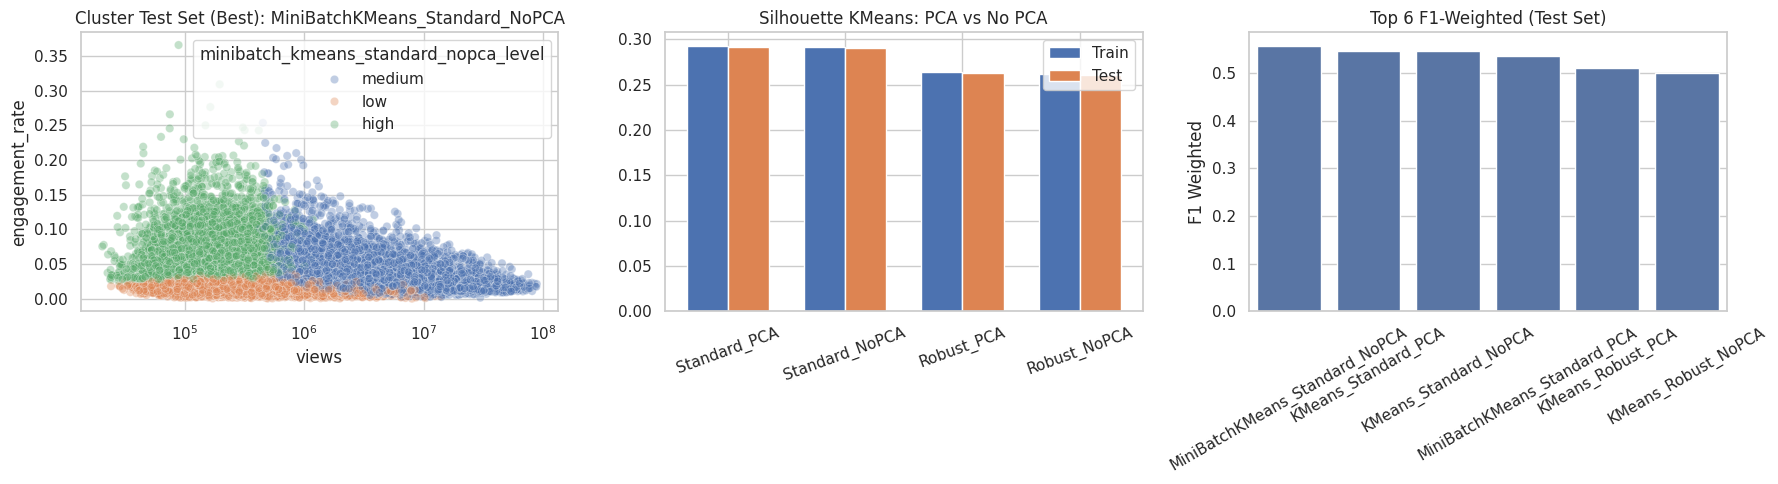


Contoh hasil cluster terbaik pada Test Set bersih:


,views,engagement_rate,engagement_class,minibatch_kmeans_standard_nopca_level
17132,994468,0.024754,medium,medium
18821,870421,0.050014,medium,medium
41376,196778,0.010565,low,low
19679,814276,0.061800,high,medium
19537,822523,0.036056,medium,low


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Scatter plot model terbaik pada Test Set bersih (Generalisasi)
df_test_clean_best = df_test[best_model_info["inliers_test"]].copy()
sns.scatterplot(
    data=df_test_clean_best,
    x=views_col,
    y="engagement_rate",
    hue=f"{best_prefix}_level",
    alpha=0.35,
    ax=axes[0],
)
axes[0].set_xscale("log")
axes[0].set_title(f"Cluster Test Set (Best): {best_method_name}")

# 2. Perbandingan Silhouette Score KMeans pada 4 Konfigurasi
kmeans_comps = model_comparison_df[model_comparison_df["method"].str.startswith("KMeans")].copy()
x_indices = np.arange(len(kmeans_comps))
width = 0.35
axes[1].bar(x_indices - width/2, kmeans_comps["train_silhouette"], width, label='Train')
axes[1].bar(x_indices + width/2, kmeans_comps["test_silhouette"], width, label='Test')
axes[1].set_xticks(x_indices)
axes[1].set_xticklabels(kmeans_comps["config"], rotation=20)
axes[1].set_title("Silhouette KMeans: PCA vs No PCA")
axes[1].legend()

# 3. F1-score Test Set vs Rule-based Teratas
top_models = model_comparison_df.head(6)
sns.barplot(
    data=top_models,
    x="method",
    y="test_f1_weighted",
    ax=axes[2]
)
axes[2].set_title("Top 6 F1-Weighted (Test Set)")
axes[2].set_xlabel("")
axes[2].set_ylabel("F1 Weighted")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print("\nContoh hasil cluster terbaik pada Test Set bersih:")
display(df_test_clean_best[[views_col, "engagement_rate", "engagement_class", f"{best_prefix}_level"]].head())


# Pengujian Model pada Data Baru di Luar Dataset (Out-of-Dataset Testing)

### Penjelasan Lengkap & Tujuan
Skenario ini mensimulasikan penggunaan model clustering yang telah dilatih untuk **memprediksi dan melabeli data video baru yang benar-benar asing** (di luar dataset historis yang kita miliki). Ini adalah pembuktian utama bahwa model *machine learning* tidak hanya menghafal data latihan, tetapi telah mempelajari pola representasi spasial fitur yang dapat menggeneralisasikan prediksi pada data baru di masa depan.

#### Alur Kerja Prediksi Data Baru (Bebas Leakage):
1. **Input Data Baru**: Menerima input metrik mentah video baru (`views`, `likes`, dan `comments`).
2. **Kalkulasi Metrik**: Menghitung *engagement rate* awal secara manual: $(likes + comments) / views$.
3. **Transformasi Distribusi**: Menerapkan objek `PowerTransformer` (Yeo-Johnson) yang telah di-fit pada dataset latih untuk menyelaraskan distribusi sebarannya.
4. **Transformasi Skala**: Menerapkan objek `Scaler` (Robust/Standard) yang telah di-fit pada dataset latih untuk menyamakan rentang nilai skala.
5. **Reduksi Dimensi (PCA)**: Menerapkan objek `PCA` (jika konfigurasi terbaik menggunakan PCA) yang telah di-fit pada dataset latih.
6. **Prediksi Model**: Menerapkan objek model clustering (misalnya `KMeans`) yang telah dilatih untuk menghasilkan label klaster.
7. **Mapping Kategori**: Mengubah label klaster numerik menjadi kategori tingkat engagement (`low`, `medium`, `high`) menggunakan kamus pemetaan (*mapping dictionary*) yang bersumber dari dataset latih.

In [31]:
# Simulasi Pengujian Data Baru di Luar Dataset Menggunakan Data Asli Eksternal

# 1. Ambil data asli eksternal yang telah dipisahkan di awal (Cell 4)
df_new = df_external_test.copy()

# 2. Hitung engagement_rate awal
if "engagement_rate" not in df_new.columns:
    df_new["engagement_rate"] = (df_new[likes_col] + df_new[comments_col]) / df_new[views_col]

# 3. Ambil objek preprocessing dan model terbaik hasil training
pt_trained = best_model_info["power_transformer"]
scaler_trained = best_model_info["scaler"]
pca_trained = best_model_info["pca"]
model_trained = best_model_info["model"]
cluster_map_trained = best_model_info["cluster_map"]

# 4. Terapkan pipeline preprocessing pada data baru (tanpa fit ulang untuk menghindari leakage!)
raw_features_new = pd.DataFrame({
    "views": df_new[views_col],
    "likes": df_new[likes_col],
    "comments": df_new[comments_col],
    "engagement_rate": df_new["engagement_rate"]
})

X_new_pt = pt_trained.transform(raw_features_new)
X_new_scaled = scaler_trained.transform(X_new_pt)

if pca_trained is not None:
    X_new_final = pca_trained.transform(X_new_scaled)
else:
    X_new_final = X_new_scaled

# 5. Prediksi Klaster dengan Model Terlatih
if hasattr(model_trained, "predict"):
    new_labels = model_trained.predict(X_new_final)
else:
    new_labels = model_trained.fit_predict(X_new_final)

# 6. Petakan label klaster ke tingkat engagement menggunakan pemetaan hasil training
new_levels = pd.Series(new_labels).map(cluster_map_trained).to_numpy()

# 7. Tampilkan hasil prediksi
df_new["predicted_cluster"] = new_labels
df_new["predicted_engagement_level"] = new_levels

print("Hasil Prediksi & Pelabelan Video Nyata Baru di Luar Dataset Pemodelan:")
cols_to_show = [c for c in ["video_id", "title", "channel", views_col, "engagement_rate", "predicted_cluster", "predicted_engagement_level"] if c in df_new.columns]
display(df_new[cols_to_show])


Hasil Prediksi & Pelabelan Video Nyata Baru di Luar Dataset Pemodelan:


,video_id,title,channel,views,engagement_rate,predicted_cluster,predicted_engagement_level
0,5kxvvh_znjY,Crystal Palace v Aston Villa | Key Moments | S...,The Emirates FA Cup,1533869,0.014334,2,low
1,E0GvIwtIYGo,Trump zabrania wychodzenia z systemu dolaroweg...,Strategy&Future,843809,0.017225,2,low
2,oXzjaCjxcIs,تحديت محمد عدنان في تحدي كروي مجنووون 🤯⚽ | تحد...,فياض الكندي | Fayadh Al-kindi,1110887,0.073629,1,medium
3,XjCkk4VqbUY,MarvinVlogt vs. LAMBO?! 🏎️🤿,offen un' ehrlich,995648,0.032232,2,low
4,oyaNTkYtDM8,The Taste of Kindness🥬🍣❣️,ISSEI / いっせい,28073571,0.027428,1,medium
5,9AL1oyQgKIM,"Eşref Rüya 5. Bölüm 1. Fragmanı | ""Sesinde Büy...",Eşref Rüya,4004330,0.028376,1,medium
6,BhL8fjAUyTM,Bogdan DLP - Afacere 💸 Official Video,Bogdan DLP,2616002,0.011341,1,medium
7,-mB9-ItebUE,Sindhu Bairavi Kacheri Arambam | 12th & 13th J...,Vijay Television,1629164,0.018064,2,low
8,HJlgtVLrfTE,RIP Dark JJ's Sister Squid Game Trap - MAIZEN ...,Mine Monster,1239182,0.014819,2,low
9,oO9RIXjhIEI,If fan could speak their feelings 💔😭most viral...,Bihari Ladka,20788432,0.026113,1,medium
